# 10 — The Most Improved leap, week by week

**Questions**
1. Did past Most Improved Player (MIP) winners improve **steadily through the season**, or jump at a specific point (a hot start, after the All-Star break, after a role change)?
2. Is a single huge night (Malachi Flynn's 50 points) an **indicator or a fluke**?
3. How much does a **3-, 5- or 7-game rolling average** tell you about the rest of the season?
4. (Next) Can we pick the MIP in retrospect, and was Nickeil Alexander-Walker's 2025-26 leap a **blip**?

**Decisions**
- **Production** = Hollinger **game score** (headline: one number for a game's box-score impact), shown alongside points, minutes, shot volume (shots + turnovers), assists and rebounds.
- **Baseline** = the player's per-game averages in his **most recent previous season in which he played at least 33% of the games**. Injury-shortened seasons are skipped, so a healthy return (e.g. Kawhi Leonard after his 9-game 2017-18, Derrick Rose after his 25-game 2017-18) isn't counted as improvement.
- **Form** = 3-, 5- and 7-game rolling averages; weekly averages for display.
- MIP prediction will be limited to players with **≥ 2 previous seasons** (predicting from year 3 on).

Data: NBA.com league-wide game logs, 2010-11 → 2025-26 (404k player-games; 2010-11 only supplies 2011-12 baselines).

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from unicorn.gamelogs import build_game_table
from unicorn.labels import MIP_WINNERS
from unicorn.plotting import apply_style, BLUE, ORANGE, INK, INK2, MUTED, FIG_DIR, SERIES, SURFACE
from unicorn.raw import PROJECT_ROOT

warnings.filterwarnings("ignore", category=RuntimeWarning)
apply_style()
games, base, asb = build_game_table()
games.to_parquet(PROJECT_ROOT / "data" / "processed" / "player_games.parquet", index=False)
print(games.shape)
asb

(404431, 62)


,season,last_game_before,first_game_after,gap_days
0,2010-11,2011-02-17,2011-02-22,5
1,2011-12,2012-02-23,2012-02-28,5
2,2012-13,2013-02-14,2013-02-19,5
3,2013-14,2014-02-13,2014-02-18,5
4,2014-15,2015-02-12,2015-02-19,7
5,2015-16,2016-02-11,2016-02-18,7
6,2016-17,2017-02-16,2017-02-23,7
7,2017-18,2018-02-15,2018-02-22,7
8,2018-19,2019-02-14,2019-02-21,7
9,2019-20,2020-02-13,2020-02-20,7


## 10B — How did each Most Improved winner's season unfold?

In [2]:
mip = pd.DataFrame([{"season": s, "player_id": pid} for s, pid in MIP_WINNERS.items()])
w = games.merge(mip, on=["season", "player_id"])
asb_week = games[games["after_all_star"]].groupby("season")["week"].min()

rows = []
for (s, pid), d in w.groupby(["season", "player_id"]):
    rows.append({"season": s, "player": d["player_name"].iloc[0],
                 "baseline": d["base_game_score"].iloc[0],
                 "first_10_games": d.head(10)["game_score"].mean(),
                 "before_all_star": d.loc[~d["after_all_star"], "game_score"].mean(),
                 "after_all_star": d.loc[d["after_all_star"], "game_score"].mean(),
                 "season_avg": d["game_score"].mean(),
                 "min_baseline": d["base_min"].iloc[0], "min_first_10": d.head(10)["min"].mean(), "min_season": d["min"].mean()})
summary = pd.DataFrame(rows)
summary["leap"] = summary["season_avg"] - summary["baseline"]
summary["share_of_leap_in_first_10"] = (summary["first_10_games"] - summary["baseline"]) / summary["leap"]
summary["post_vs_pre_all_star"] = summary["after_all_star"] - summary["before_all_star"]
summary.round(2)

,season,player,baseline,first_10_games,before_all_star,after_all_star,season_avg,min_baseline,min_first_10,min_season,leap,share_of_leap_in_first_10,post_vs_pre_all_star
0,2011-12,Ryan Anderson,8.48,14.20,13.25,12.80,13.05,22.17,30.6,32.16,4.57,1.25,-0.45
1,2012-13,Paul George,9.60,9.08,13.28,12.57,13.03,29.59,36.8,37.59,3.43,-0.15,-0.70
2,2013-14,Goran Dragic,12.54,11.88,16.27,14.81,15.73,33.53,32.3,35.13,3.19,-0.21,-1.46
3,2014-15,Jimmy Butler III,10.98,18.46,17.40,16.16,17.09,38.70,39.9,38.69,6.11,1.22,-1.24
4,2015-16,CJ McCollum,4.34,12.75,13.29,13.98,13.53,15.69,34.7,34.70,9.19,0.91,0.69
5,2016-17,Giannis Antetokounmpo,14.16,19.01,20.85,19.45,20.40,35.31,34.1,35.59,6.23,0.78,-1.41
6,2017-18,Victor Oladipo,10.48,16.59,18.27,15.73,17.49,33.21,32.5,34.08,7.01,0.87,-2.55
7,2018-19,Pascal Siakam,6.65,10.52,13.58,15.15,14.01,20.65,26.9,31.86,7.36,0.53,1.57
8,2019-20,Brandon Ingram,11.77,18.64,17.93,12.72,16.67,33.87,32.4,33.95,4.89,1.40,-5.21
9,2020-21,Julius Randle,13.74,18.36,18.29,18.07,18.18,32.53,37.8,37.55,4.45,1.04,-0.22


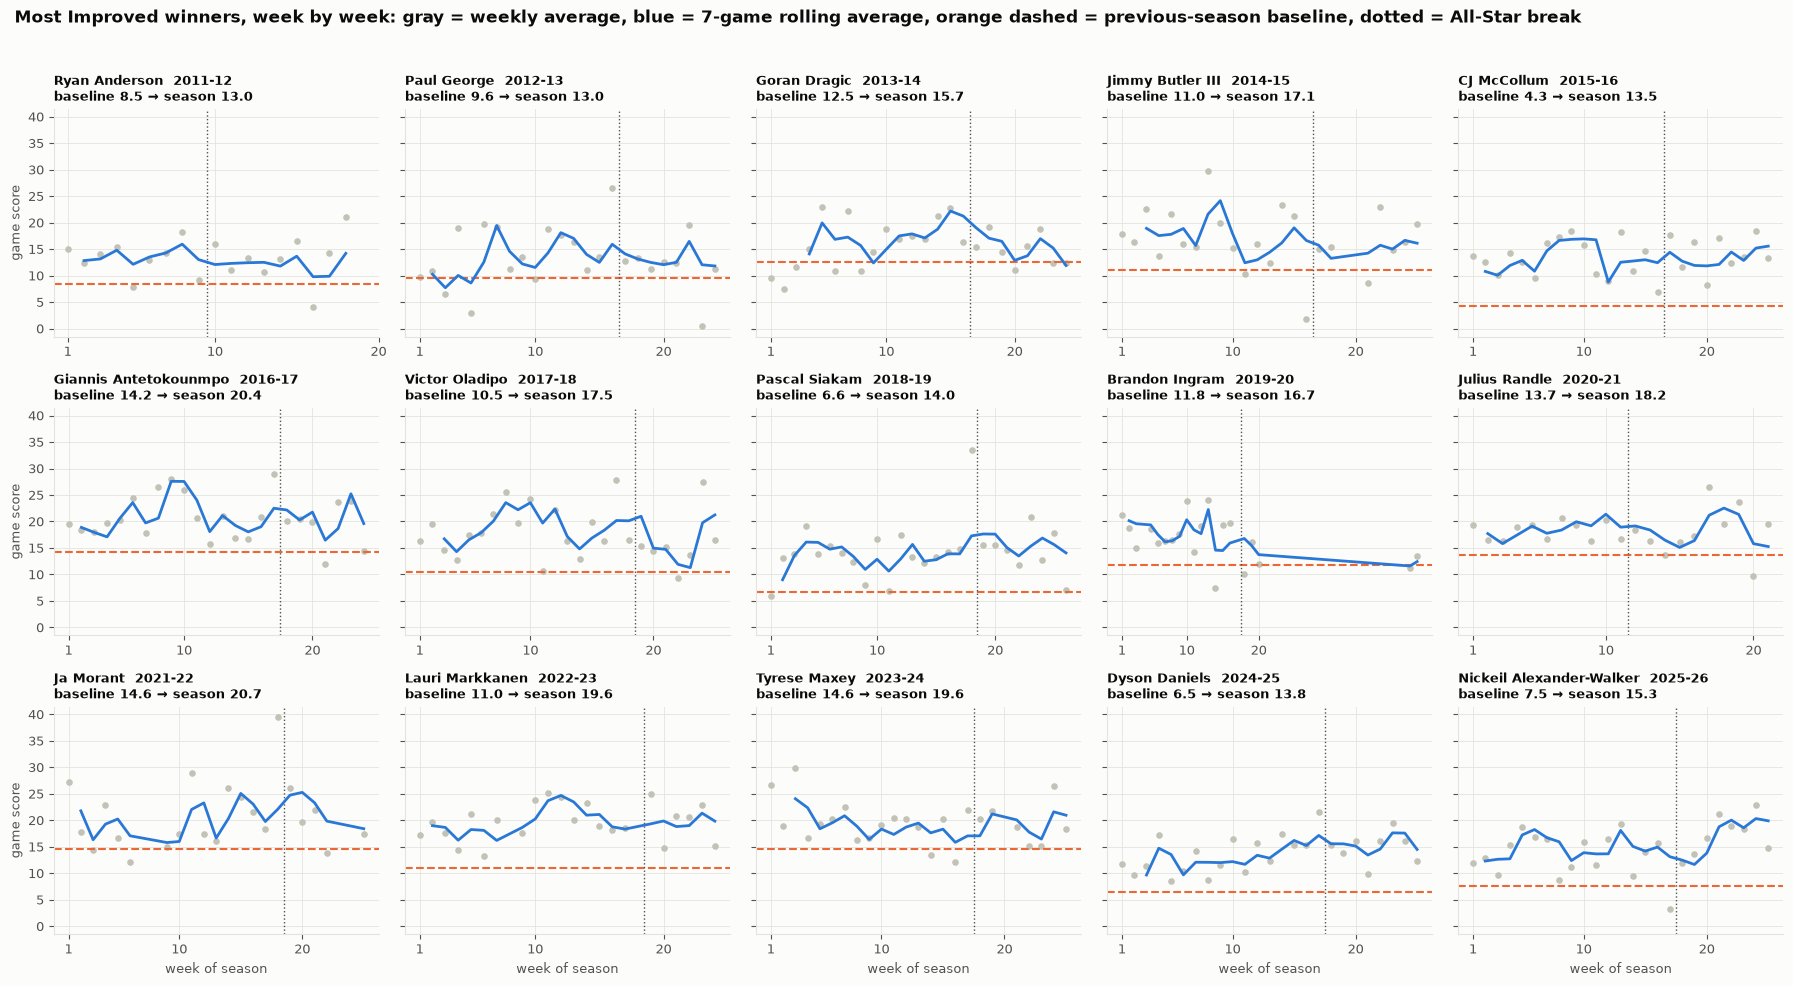

In [3]:
winners = summary.sort_values("season")
fig, axes = plt.subplots(3, 5, figsize=(18, 10), sharey=True)
for ax, (_, r) in zip(axes.flat, winners.iterrows()):
    d = w[(w["season"] == r["season"]) & (w["player_name"] == r["player"])]
    weekly = d.groupby("week")["game_score"].mean()
    roll = d.groupby("week")["game_score_roll7"].last()
    ax.scatter(weekly.index, weekly.values, s=14, color=MUTED, zorder=2)
    ax.plot(roll.index, roll.values, color=BLUE, linewidth=2, zorder=3)
    ax.axhline(r["baseline"], color=ORANGE, linestyle="--", linewidth=1.5)
    ax.axvline(asb_week[r["season"]] - 0.5, color=INK2, linestyle=":", linewidth=1)
    ax.set_title(f"{r['player']}  {r['season']}\nbaseline {r['baseline']:.1f} → season {r['season_avg']:.1f}", loc="left", fontsize=9.5)
    ax.set_xticks([1, 10, 20])
for ax in axes[:, 0]:
    ax.set_ylabel("game score")
for ax in axes[-1]:
    ax.set_xlabel("week of season")
fig.suptitle("Most Improved winners, week by week: gray = weekly average, blue = 7-game rolling average, "
             "orange dashed = previous-season baseline, dotted = All-Star break", x=0.01, ha="left", fontsize=12, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.96)); fig.savefig(FIG_DIR / "10_mip_week_by_week.png", dpi=150, bbox_inches="tight")

## 10C — One huge night: indicator or fluke?

An **eruption** is a game with a game score at least **20 above the player's baseline** (Flynn's 50: 42.0 vs a baseline of 3.0). Compare how the player did in the **7 games before** and the **7 games after** against his baseline.

In [4]:
g = games[games["base_game_score"].notna()].copy()
g["excess"] = g["game_score"] - g["base_game_score"]
ps = g.groupby(["player_id", "season_start"])["excess"]
g["prev7"] = ps.transform(lambda s: s.shift(1).rolling(7, min_periods=7).mean())
g["next7"] = ps.transform(lambda s: s[::-1].shift(1).rolling(7, min_periods=7).mean()[::-1])
eruptions = g[g["excess"] >= 20].dropna(subset=["prev7", "next7"])
others = g.dropna(subset=["prev7", "next7"])
print(f"{len(eruptions)} eruption games (with 7 games either side) out of {len(others):,} games")
print(f"after an eruption, next 7 games vs baseline: {eruptions['next7'].mean():+.1f} game score "
      f"(the 7 before: {eruptions['prev7'].mean():+.1f}); for all games: next 7 {others['next7'].mean():+.1f}")
flynn = g[(g["player_name"] == "Malachi Flynn") & (g["pts"] >= 50)]
display(flynn[["season", "game_date", "matchup", "min", "pts", "game_score", "base_game_score", "prev7", "next7"]].round({"game_score": 1, "base_game_score": 1, "prev7": 1}))
print("Flynn's remaining games that season:")
f_season = g[(g["player_name"] == "Malachi Flynn") & (g["season"] == flynn["season"].iloc[0])]
display(f_season[f_season["game_date"] >= flynn["game_date"].iloc[0]][["game_date", "matchup", "min", "pts", "game_score"]])

1089 eruption games (with 7 games either side) out of 237,803 games
after an eruption, next 7 games vs baseline: +3.4 game score (the 7 before: +3.1); for all games: next 7 +0.3


,season,game_date,matchup,min,pts,game_score,base_game_score,prev7,next7
356021,2023-24,2024-04-03,DET @ ATL,34.0,50,42.0,3.0,4.7,NaN


Flynn's remaining games that season:


,game_date,matchup,min,pts,game_score
356021,2024-04-03,DET @ ATL,34.0,50,42.0
356022,2024-04-05,DET @ MEM,23.0,3,-1.3
356023,2024-04-06,DET @ BKN,15.0,3,-0.1
356024,2024-04-09,DET @ PHI,21.0,12,7.7
356025,2024-04-11,DET vs. CHI,15.0,12,5.9
356026,2024-04-12,DET @ DAL,16.0,10,12.1
356027,2024-04-14,DET @ SAS,20.0,4,1.6


In [5]:
# Was the eruption a sign of a real step up? Bucket by what the 7 games BEFORE looked like
eruptions = eruptions.assign(form_before=pd.cut(eruptions["prev7"], [-99, 0, 3, 99], labels=["below baseline", "slightly above (0–3)", "already well above (3+)"]))
t = eruptions.groupby("form_before", observed=True).agg(eruptions=("next7", "size"), next7_vs_baseline=("next7", "mean"),
                                                         prev7_vs_baseline=("prev7", "mean"))
t.round(2)

,eruptions,next7_vs_baseline,prev7_vs_baseline
form_before,,,
below baseline,240,0.97,-2.02
slightly above (0–3),316,2.55,1.62
already well above (3+),533,5.06,6.36


## 10D — How much do 3, 5 and 7-game averages tell you?

At a given point in the season (after game *n*), take the player's last-*k*-games average (relative to his baseline) and see how well it predicts his **rest-of-season** average (also relative to baseline). Correlation across all player-seasons with at least *n* + 15 games, ≥ 15 min per game in the baseline season.

window,last game,last 3,last 5,last 7,season to date
after game,,,,,
7,0.32,0.44,0.53,0.56,0.56
15,0.31,0.44,0.52,0.56,0.63
25,0.31,0.46,0.53,0.58,0.68
40,0.32,0.47,0.53,0.58,0.68


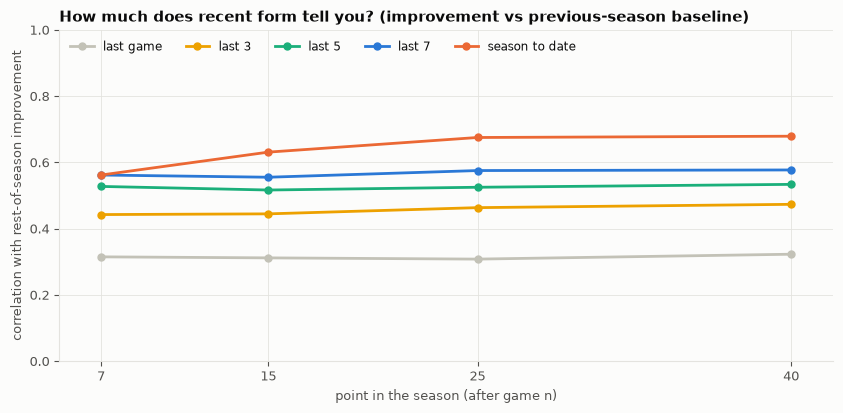

In [6]:
rows = []
gg = g[g["base_min"] >= 15].copy()
gg["games_in_season"] = gg.groupby(["player_id", "season_start"])["game_number"].transform("max")
for n in [7, 15, 25, 40]:
    cut = gg[gg["games_in_season"] >= n + 15]
    at_n = cut[cut["game_number"] == n].set_index(["player_id", "season_start"])
    rest = cut[cut["game_number"] > n].groupby(["player_id", "season_start"])["excess"].mean()
    to_date = cut[cut["game_number"] <= n].groupby(["player_id", "season_start"])["excess"].mean()
    preds = {"last game": at_n["excess"], **{f"last {k}": at_n[f"game_score_roll{k}"] - at_n["base_game_score"] for k in (3, 5, 7)},
             "season to date": to_date}
    for name, p in preds.items():
        rows.append({"after game": n, "window": name, "corr_with_rest_of_season": p.corr(rest.reindex(p.index)), "player_seasons": len(p)})
corr = pd.DataFrame(rows).pivot(index="after game", columns="window", values="corr_with_rest_of_season")
corr = corr[["last game", "last 3", "last 5", "last 7", "season to date"]]

fig, ax = plt.subplots(figsize=(8.5, 4.2))
for name, color in zip(corr.columns, [MUTED, SERIES[3], SERIES[2], SERIES[0], SERIES[1]]):
    ax.plot(corr.index, corr[name], color=color, marker="o", markersize=5, label=name)
ax.set_xticks(corr.index); ax.set_xlim(5, 42); ax.set_ylim(0, 1)
ax.set_xlabel("point in the season (after game n)"); ax.set_ylabel("correlation with rest-of-season improvement")
ax.legend(frameon=False, loc="upper left", ncol=5, fontsize=8.5)
ax.set_title("How much does recent form tell you? (improvement vs previous-season baseline)", loc="left")
fig.tight_layout(); fig.savefig(FIG_DIR / "10_rolling_window_signal.png", dpi=150, bbox_inches="tight")
corr.round(2)

## Findings so far

**How winners' seasons unfolded (10B):**
- **Most MIP leaps were there from day one.** For 11 of 15 winners, the first 10 games already showed 80%+ of the full-season jump in game score. The leap usually came with a **new role from opening night**: McCollum 15.7 → 34.7 minutes, Daniels 22.3 → 33.0, Anderson 22.2 → 30.6.
- **Three grew into it during the season:** Paul George and Dragić started at their baseline and climbed; Siakam showed half the leap early, then kept rising.
- **The All-Star break rarely mattered.** Most winners were flat or slightly *down* after it (Ingram −5.2, mostly the 2020 bubble). The exceptions rose: **Nickeil Alexander-Walker +3.7** (14.2 → 17.9), Daniels +1.9, Siakam +1.6.
- **NAW is the strongest late riser of all 15 winners.** He had only half his leap in the first 10 games, his minutes kept growing (30 → 33), and his best form came after the All-Star break (7-game average about 20 by season's end). Whether that late surge carries into 2026-27 is the "blip or real" question.

**One huge night: indicator or fluke? (10C)**
- Across 1,109 "eruption" games (game score ≥ 20 above baseline), the next 7 games averaged **+3.5 above baseline**, almost identical to the 7 games *before* (+3.1). **The eruption itself adds little; it mostly confirms form that was already there.**
- If the player was *below* his baseline before the eruption, the next 7 games averaged only +1.0. **Flynn is that case:** +4.7 in the 7 games before his 50-pointer, then game scores of −1.3, −0.1, 7.7, 5.9, 12.1 and 1.6 to finish the season. **A fluke.**

**Which window to trust (10D):**
- **A single game is a weak signal** (correlation about 0.3 with rest-of-season improvement); 3 games about 0.45, 5 about 0.53, 7 about 0.57.
- **Season-to-date wins once there are 15+ games** (0.63 → 0.68). The 7-game average is the best *short-term* gauge, but it never beats the full sample.

**Next:** (1) **blip or real**: what share of the leap winners and other big leapers keep the next season, and what predicts keeping it (age, early vs late leap, minutes change, shooting luck); (2) **pick the MIP in retrospect** for players with ≥ 2 previous seasons, including "who led at the All-Star break?".

## 10E — Picking the MIP in retrospect: our top 3 each season vs the actual winner

**Score (this section) = points-per-game change vs the player's own most recent previous season.** A player going 6 → 17 ppg (+11) outranks one going 17 → 24 (+7), because MIP is about improving *on yourself*. 10F below uses changes in **every** stat.

**Eligible** (same rule every season; the 65-game award rule is deliberately ignored):
- **≥ 2 previous NBA seasons** (year 3 onwards);
- a previous season to compare against;
- **at least half the season's games**, so a short hot streak can't win.

MIP voting happens after the season, so using the full season is fair.

In [7]:
from unicorn.gamelogs import mip_candidates

ps = pd.read_parquet(PROJECT_ROOT / "data" / "processed" / "player_season.parquet")
cand = mip_candidates(games, ps)
cand["mip"] = [MIP_WINNERS.get(s) == p for s, p in zip(cand["season"], cand["player_id"])]
el = cand[cand["eligible"] & (cand["season_start"] >= 2011)].copy()
el["rank"] = el.groupby("season")["ppg_delta"].rank(ascending=False, method="min").astype(int)
el["rank_game_score"] = el.groupby("season")["game_score_delta"].rank(ascending=False, method="min").astype(int)

rows = []
for s, d in el.groupby("season"):
    top = d.nsmallest(3, "rank")
    win = d[d["mip"]].iloc[0]
    rows.append({"season": s, **{f"#{i + 1}": f"{r.player_name} (+{r.ppg_delta:.1f})" for i, r in enumerate(top.itertuples())},
                 "actual winner": f"{win.player_name} (+{win.ppg_delta:.1f})", "winner rank": win["rank"],
                 "winner rank (game score)": win["rank_game_score"], "eligible players": len(d)})
board = pd.DataFrame(rows).set_index("season")
print(f"winner in our top 3: {(board['winner rank'] <= 3).sum()}/{len(board)} | ranked #1: {(board['winner rank'] == 1).sum()} "
      f"| top 3 by game-score change: {(board['winner rank (game score)'] <= 3).sum()}/{len(board)}")
board

winner in our top 3: 8/15 | ranked #1: 5 | top 3 by game-score change: 9/15


,#1,#2,#3,actual winner,winner rank,winner rank (game score),eligible players
season,,,,,,,
2011-12,Jeff Teague (+7.4),Andrew Bynum (+7.4),Jarrett Jack (+6.7),Ryan Anderson (+5.4),8,4,241
2012-13,James Harden (+9.1),Stephen Curry (+8.2),Omer Asik (+7.0),Paul George (+5.3),9,17,254
2013-14,Eric Bledsoe (+9.3),Gerald Green (+8.8),D.J. Augustin (+8.4),Goran Dragic (+5.6),18,27,255
2014-15,Jimmy Butler III (+6.9),Wayne Ellington (+6.8),Donatas Motiejunas (+6.5),Jimmy Butler III (+6.9),1,1,272
2015-16,CJ McCollum (+14.0),Will Barton (+7.5),Danilo Gallinari (+7.1),CJ McCollum (+14.0),1,1,273
2016-17,Russell Westbrook (+8.1),Tim Hardaway Jr. (+8.1),James Johnson (+7.8),Giannis Antetokounmpo (+6.0),10,2,269
2017-18,Tyreke Evans (+9.1),Jonathon Simmons (+7.7),Victor Oladipo (+7.2),Victor Oladipo (+7.2),3,2,251
2018-19,Pascal Siakam (+9.7),Malik Beasley (+8.2),JaVale McGee (+7.2),Pascal Siakam (+9.7),1,1,261
2019-20,Terry Rozier (+9.0),Damion Lee (+7.7),Jayson Tatum (+7.7),Brandon Ingram (+5.6),14,10,241


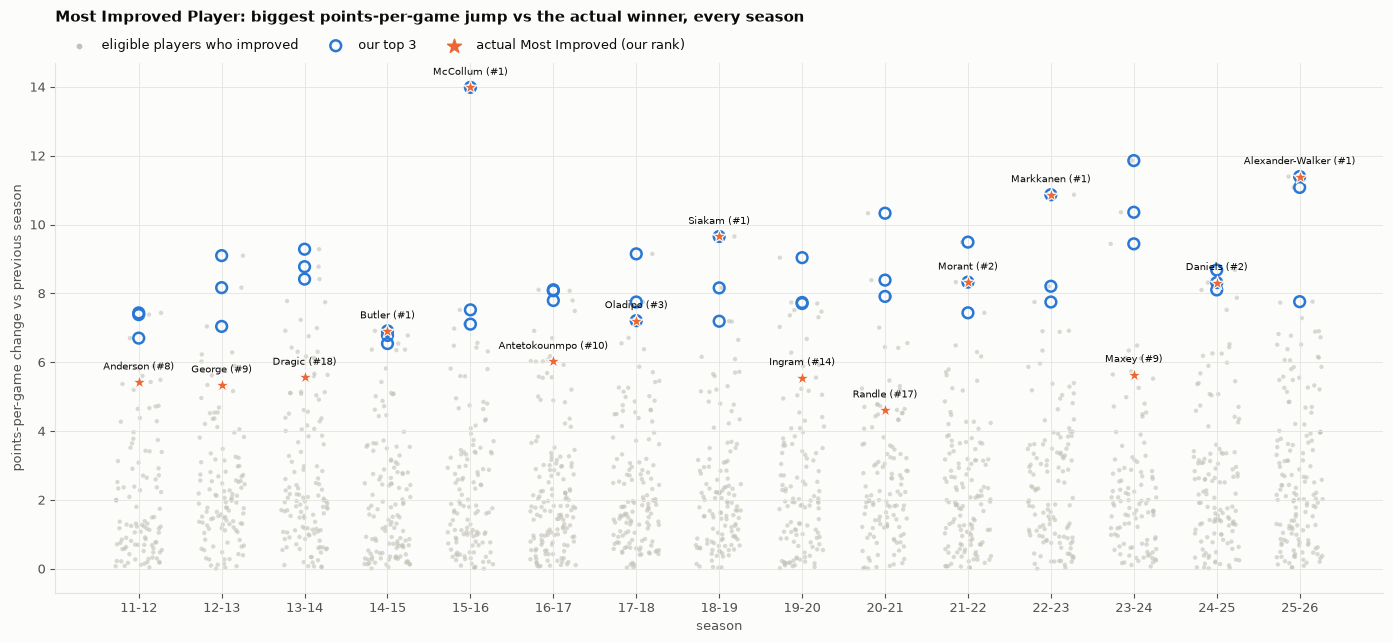

In [8]:
def short(name):
    return [p for p in name.split() if p not in {"Jr.", "Sr.", "II", "III", "IV"}][-1]

fig, ax = plt.subplots(figsize=(14, 6.5))
seasons = sorted(el["season"].unique())
rng = np.random.default_rng(0)
for i, s in enumerate(seasons):
    d = el[(el["season"] == s) & (el["ppg_delta"] > 0)]
    x = i + rng.uniform(-0.28, 0.28, len(d))
    ax.scatter(x, d["ppg_delta"], s=10, color=MUTED, alpha=0.6, edgecolor="none", zorder=1)
    top = d.nsmallest(3, "rank")
    ax.scatter(np.full(len(top), i), top["ppg_delta"], s=60, facecolor="none", edgecolor=BLUE, linewidth=1.8, zorder=3)
    w_ = d[d["mip"]]
    if len(w_):
        r = w_.iloc[0]
        ax.scatter([i], [r["ppg_delta"]], s=110, marker="*", color=ORANGE, edgecolor=SURFACE, linewidth=0.8, zorder=4)
        ax.annotate(f"{short(r['player_name'])} (#{r['rank']})", (i, r["ppg_delta"]), xytext=(0, 9),
                    textcoords="offset points", ha="center", fontsize=7.5, color=INK)
ax.set_xticks(range(len(seasons)), [s[2:] for s in seasons])
ax.set_ylabel("points-per-game change vs previous season"); ax.set_xlabel("season")
ax.scatter([], [], s=10, color=MUTED, label="eligible players who improved")
ax.scatter([], [], s=60, facecolor="none", edgecolor=BLUE, linewidth=1.8, label="our top 3")
ax.scatter([], [], s=110, marker="*", color=ORANGE, label="actual Most Improved (our rank)")
ax.legend(frameon=False, loc="lower left", bbox_to_anchor=(0, 1.0), ncol=3)
ax.set_title("Most Improved Player: biggest points-per-game jump vs the actual winner, every season", loc="left", pad=30)
fig.tight_layout(); fig.savefig(FIG_DIR / "10_mip_top3_vs_winner.png", dpi=150, bbox_inches="tight")

In [9]:
print("2025-26: the top candidates")
cols = ["player_name", "team", "base_ppg", "ppg", "ppg_delta", "game_score_delta", "mpg_delta", "award_games", "rank", "mip"]
el[el["season"] == "2025-26"].nsmallest(8, "rank")[cols].round(1).reset_index(drop=True)

2025-26: the top candidates


,player_name,team,base_ppg,ppg,ppg_delta,game_score_delta,mpg_delta,award_games,rank,mip
0,Nickeil Alexander-Walker,ATL,9.4,20.8,11.4,7.8,8.1,78,1,True
1,Ryan Rollins,MIL,6.2,17.3,11.1,8.5,17.5,74,2,False
2,Lauri Markkanen,UTA,19.0,26.7,7.8,7.0,3.0,42,3,False
3,Jalen Duren,DET,11.8,19.5,7.7,5.1,2.1,67,4,False
4,Deni Avdija,POR,16.9,24.2,7.3,5.1,3.3,65,5,False
5,Andrew Nembhard,IND,10.0,16.9,6.9,4.8,2.4,57,6,False
6,Tre Jones,CHI,7.2,14.1,6.9,5.3,7.3,65,7,False
7,Keyonte George,UTA,16.8,23.6,6.8,6.1,1.6,53,8,False


### 10E findings (points-per-game change only)

- **The winner is in our top 3 in 8 of 15 seasons, and #1 in 5** (Butler 2014-15, McCollum 2015-16, Siakam 2018-19, Markkanen 2022-23, NAW 2025-26). Ranking by game-score change instead: top 3 in 9.
- **2025-26:** NAW (+11.4), **Ryan Rollins (+11.1)**, Lauri Markkanen (+7.8), then Jalen Duren and Deni Avdija.
- **The misses are already-decent players who jumped to All-Star level:** Dragić, Randle, Paul George, Ryan Anderson. A points-per-game change alone undersells them; 10F adds the other stats.

## 10F — A probability for every player: changes in every stat

**Inputs:** each player's change vs his previous season in points, rebounds, assists, minutes, game score, true shooting, usage and start rate (usage and start rate are missing for 2011-12 and treated as "no change").

**Model: a choice model (conditional logit).** Each season exactly one eligible player wins. The model gives every player a score, a weighted sum of his improvements, and converts scores into **win probabilities that sum to 100% within the season**. The weights are learned from the 15 past votes, so they show **what voters actually reward**.

**Honest evaluation:** every season's probabilities come from a model that never saw that season. Main version: **trained on all the other seasons**. Strict version: **trained on earlier seasons only** (from 2016-17, once 5 seasons exist). The regularization strength is also chosen without the held-out season.

In [10]:
from unicorn.mip import DELTAS, ChoiceModel, out_of_sample_probabilities, summarize

e = el.reset_index(drop=True)
results, probs = {}, {}
for name, feats in {"points-per-game change only": ["ppg_delta"], "all stat changes": DELTAS}.items():
    for scheme, label in [("loso", "trained on all other seasons"), ("walk_forward", "trained on earlier seasons only")]:
        probs[(name, scheme)] = out_of_sample_probabilities(e, feats, scheme)
        results[(name, label)] = summarize(e, probs[(name, scheme)])
pd.DataFrame(results).T.round(3)

seasons  \
points-per-game change only trained on all other seasons        15.0   
                            trained on earlier seasons only     10.0   
all stat changes            trained on all other seasons        15.0   
                            trained on earlier seasons only     10.0   

                                                             winner #1  \
points-per-game change only trained on all other seasons           5.0   
                            trained on earlier seasons only        3.0   
all stat changes            trained on all other seasons           7.0   
                            trained on earlier seasons only        4.0   

                                                             winner top 3  \
points-per-game change only trained on all other seasons              8.0   
                            trained on earlier seasons only           6.0   
all stat changes            trained on all other seasons             10.0   
                            trained on earlier seasons only           6.0   

                                                             median winner rank  \
points-per-game change only trained on all other seasons                    3.0   
                            trained on earlier seasons only                 2.5   
all stat changes            trained on all other seasons                    2.0   
                            trained on earlier seasons only                 2.0   

                                                             mean winner probability  \
points-per-game change only trained on all other seasons                       0.176   
                            trained on earlier seasons only                    0.160   
all stat changes            trained on all other seasons                       0.273   
                            trained on earlier seasons only                    0.269   

                                                             log-likelihood vs random pick  
points-per-game change only trained on all other seasons                             2.745  
                            trained on earlier seasons only                          2.798  
all stat changes            trained on all other seasons                             3.197  
                            trained on earlier seasons only                          3.448

mpg_delta          -0.90
start_rate_delta   -0.21
apg_delta          -0.01
rpg_delta           0.03
ts_delta            0.08
usg_delta           0.41
ppg_delta           1.12
game_score_delta    2.03
dtype: float64

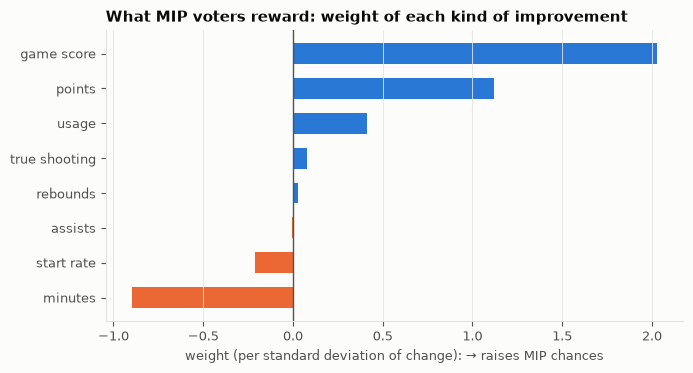

In [11]:
coef = ChoiceModel(DELTAS, l2=1.0).fit(e).coefficients().sort_values()
labels = {"ppg_delta": "points", "rpg_delta": "rebounds", "apg_delta": "assists", "mpg_delta": "minutes",
          "game_score_delta": "game score", "ts_delta": "true shooting", "usg_delta": "usage", "start_rate_delta": "start rate"}
fig, ax = plt.subplots(figsize=(7, 3.8))
ax.barh([labels[c] for c in coef.index], coef.values, color=np.where(coef > 0, BLUE, ORANGE), height=0.6)
ax.axvline(0, color=INK2, linewidth=1); ax.grid(axis="y", visible=False)
ax.set_xlabel("weight (per standard deviation of change): → raises MIP chances")
ax.set_title("What MIP voters reward: weight of each kind of improvement", loc="left")
fig.tight_layout(); fig.savefig(FIG_DIR / "10_mip_vote_weights.png", dpi=150, bbox_inches="tight")
coef.round(2)

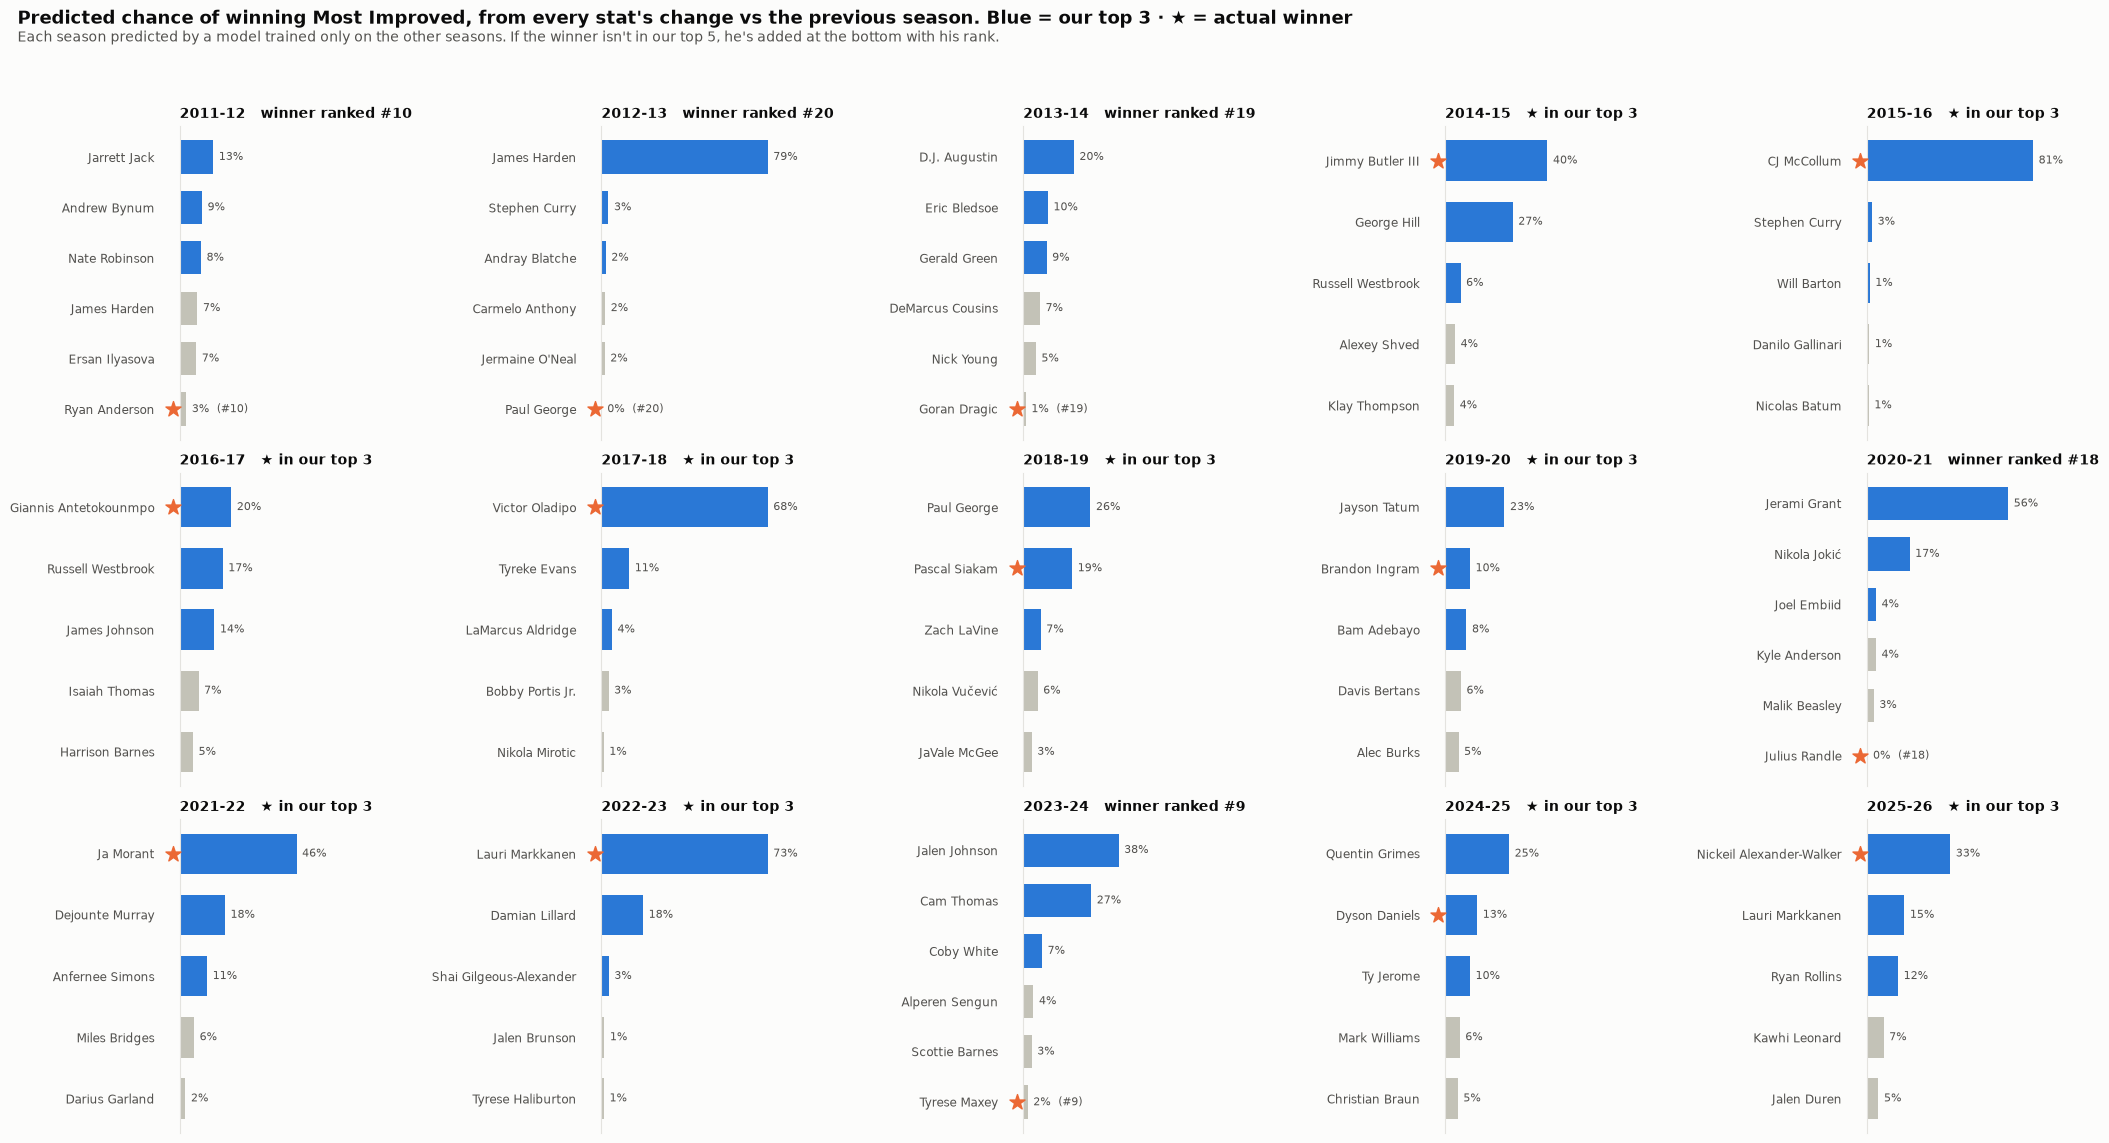

In [12]:
from unicorn.mip import probability_bars

P = e.assign(p=probs[("all stat changes", "loso")])
probability_bars(P, "Predicted chance of winning Most Improved, from every stat's change vs the previous season. Blue = our top 3 · ★ = actual winner",
                 "Each season predicted by a model trained only on the other seasons. If the winner isn't in our top 5, he's added at the bottom with his rank.",
                 FIG_DIR / "10_mip_probability_bars.png");

In [13]:
P["rank"] = P.groupby("season")["p"].rank(ascending=False, method="min").astype(int)
print("2025-26: top candidates by predicted chance")
cols = ["player_name", "team", "p", "rank", "ppg_delta", "game_score_delta", "mpg_delta", "usg_delta", "start_rate_delta", "mip"]
P[P["season"] == "2025-26"].nsmallest(8, "rank")[cols].round(3).reset_index(drop=True)

2025-26: top candidates by predicted chance


,player_name,team,p,rank,ppg_delta,game_score_delta,mpg_delta,usg_delta,start_rate_delta,mip
0,Nickeil Alexander-Walker,ATL,0.328,1,11.394,7.827,8.079,0.075,0.788,True
1,Lauri Markkanen,UTA,0.148,2,7.759,6.991,2.998,0.038,0.000,False
2,Ryan Rollins,MIL,0.124,3,11.079,8.481,17.505,0.057,0.566,False
3,Kawhi Leonard,LAC,0.067,4,6.379,5.937,0.270,0.046,0.000,False
4,Jalen Duren,DET,0.046,5,7.731,5.058,2.142,0.070,0.000,False
5,Keyonte George,UTA,0.039,6,6.820,6.101,1.641,0.038,0.478,False
6,Andrew Nembhard,IND,0.033,7,6.901,4.839,2.364,0.070,0.000,False
7,Micah Potter,IND,0.026,8,5.482,4.585,0.772,0.072,-0.114,False


### 10F findings

- **Changes in every stat beat the points-per-game change alone.** Winner ranked #1 in **7** seasons (vs 5) and in our **top 3 in 10 of 15** (vs 8); median winner rank 2; the winner's average predicted chance is **27%** (a random pick from about 250 eligible players would give about 0.4%).
- **Strict check (trained on earlier seasons only, 2016-17 → 2025-26):** winner #1 in 4 of 10 seasons, top 3 in 6.
- **What voters reward** (model weights):
  - **all-round game-score jump** (by far the strongest);
  - points;
  - usage;
  - **gaining minutes counts *against* a player, all else equal.** A jump that only comes from playing more is less impressive than producing more per minute.
- **2025-26:** NAW **33%** (#1, won), Lauri Markkanen 15%, Ryan Rollins 12%, Kawhi Leonard 7%, Jalen Duren 5%.
- **Baseline fix matters:** before requiring the baseline season to cover 33% of the games, injury comebacks (Kawhi Leonard 2018-19 vs his 9-game 2017-18; Stephen Curry 2020-21 vs a 5-game 2019-20; Derrick Rose 2018-19 vs a 25-game 2017-18) looked like huge leaps and crowded out real winners.

## 10G — Defense and relative change (and what didn't help)

Ideas tested one at a time, each judged on **seasons the model never saw**:
- **Defense:** changes in steals and blocks per game, and in on-court defensive rating (lower is better).
- **Relative change (%delta):** the log ratio of this season to last. Going 1 → 11 ppg is a far bigger *relative* jump than 21 → 31.
- **Level reached:** where he ended up (game score, points, our star score, became a starter) and where he started. This also tests whether voters discount **already-elite** players.

Age is parked for later.

In [14]:
from unicorn.labels import add_labels, add_star_score
from unicorn.mip import DEFENSE, LEVEL, RELATIVE, SEASON_LEVEL

levels = add_star_score(add_labels(pd.read_parquet(PROJECT_ROOT / "data" / "processed" / "player_season_unicorn.parquet")))
cand2 = mip_candidates(games, ps, levels=levels[["player_id", "season_start", "star_score"]])
cand2["mip"] = [MIP_WINNERS.get(s) == p for s, p in zip(cand2["season"], cand2["player_id"])]
e2 = cand2[cand2["eligible"] & (cand2["season_start"] >= 2011)].reset_index(drop=True)

SETS = {"changes": DELTAS, "changes + defense": DELTAS + DEFENSE, "changes + relative": DELTAS + RELATIVE,
        "changes + defense + relative": DELTAS + DEFENSE + RELATIVE,
        "+ level reached": DELTAS + DEFENSE + RELATIVE + LEVEL + SEASON_LEVEL}
cmp_rows, probs2 = {}, {}
for name, feats in SETS.items():
    probs2[name] = out_of_sample_probabilities(e2, feats, "loso")
    w = ChoiceModel(feats, l2=1.0).fit(e2).coefficients()
    cmp_rows[name] = {**summarize(e2, probs2[name]), "starting-level weight": w.get("base_game_score", np.nan)}
pd.DataFrame(cmp_rows).T.round(3)

,seasons,winner #1,winner top 3,median winner rank,mean winner probability,log-likelihood vs random pick,starting-level weight
changes,15.0,7.0,10.0,2.0,0.273,3.197,NaN
changes + defense,15.0,6.0,10.0,2.0,0.256,3.106,NaN
changes + relative,15.0,6.0,10.0,2.0,0.270,3.278,NaN
changes + defense + relative,15.0,7.0,10.0,2.0,0.245,3.128,NaN
+ level reached,15.0,4.0,10.0,2.0,0.199,3.094,-0.422


final model, strict check (trained on earlier seasons only): {'seasons': 10, 'winner #1': 4, 'winner top 3': 6, 'median winner rank': 2.5, 'mean winner probability': 0.245, 'log-likelihood vs random pick': 3.344}


mpg_delta          -0.60
ppg_rel            -0.57
def_rating_delta   -0.31
start_rate_delta   -0.23
game_score_rel     -0.22
bpg_delta          -0.09
apg_delta           0.01
rpg_delta           0.23
ts_delta            0.36
spg_delta           0.37
usg_delta           0.54
ppg_delta           1.41
game_score_delta    1.78
dtype: float64

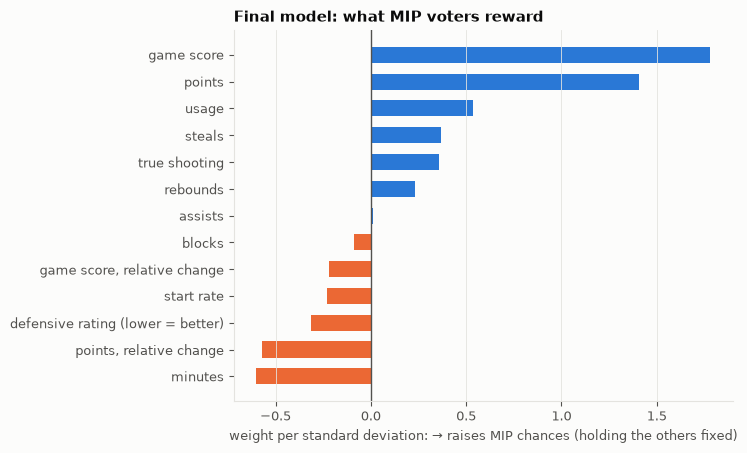

In [15]:
FINAL = SETS["changes + defense + relative"]
strict = summarize(e2, out_of_sample_probabilities(e2, FINAL, "walk_forward"))
print("final model, strict check (trained on earlier seasons only):", {k: round(v, 3) for k, v in strict.items()})
final_w = ChoiceModel(FINAL, l2=1.0).fit(e2).coefficients().sort_values()
names = {**labels, "ppg_rel": "points, relative change", "game_score_rel": "game score, relative change",
         "spg_delta": "steals", "bpg_delta": "blocks", "def_rating_delta": "defensive rating (lower = better)"}
fig, ax = plt.subplots(figsize=(7.5, 4.6))
ax.barh([names[c] for c in final_w.index], final_w.values, color=np.where(final_w > 0, BLUE, ORANGE), height=0.6)
ax.axvline(0, color=INK2, linewidth=1); ax.grid(axis="y", visible=False)
ax.set_xlabel("weight per standard deviation: → raises MIP chances (holding the others fixed)")
ax.set_title("Final model: what MIP voters reward", loc="left")
fig.tight_layout(); fig.savefig(FIG_DIR / "10_mip_vote_weights_final.png", dpi=150, bbox_inches="tight")
final_w.round(2)

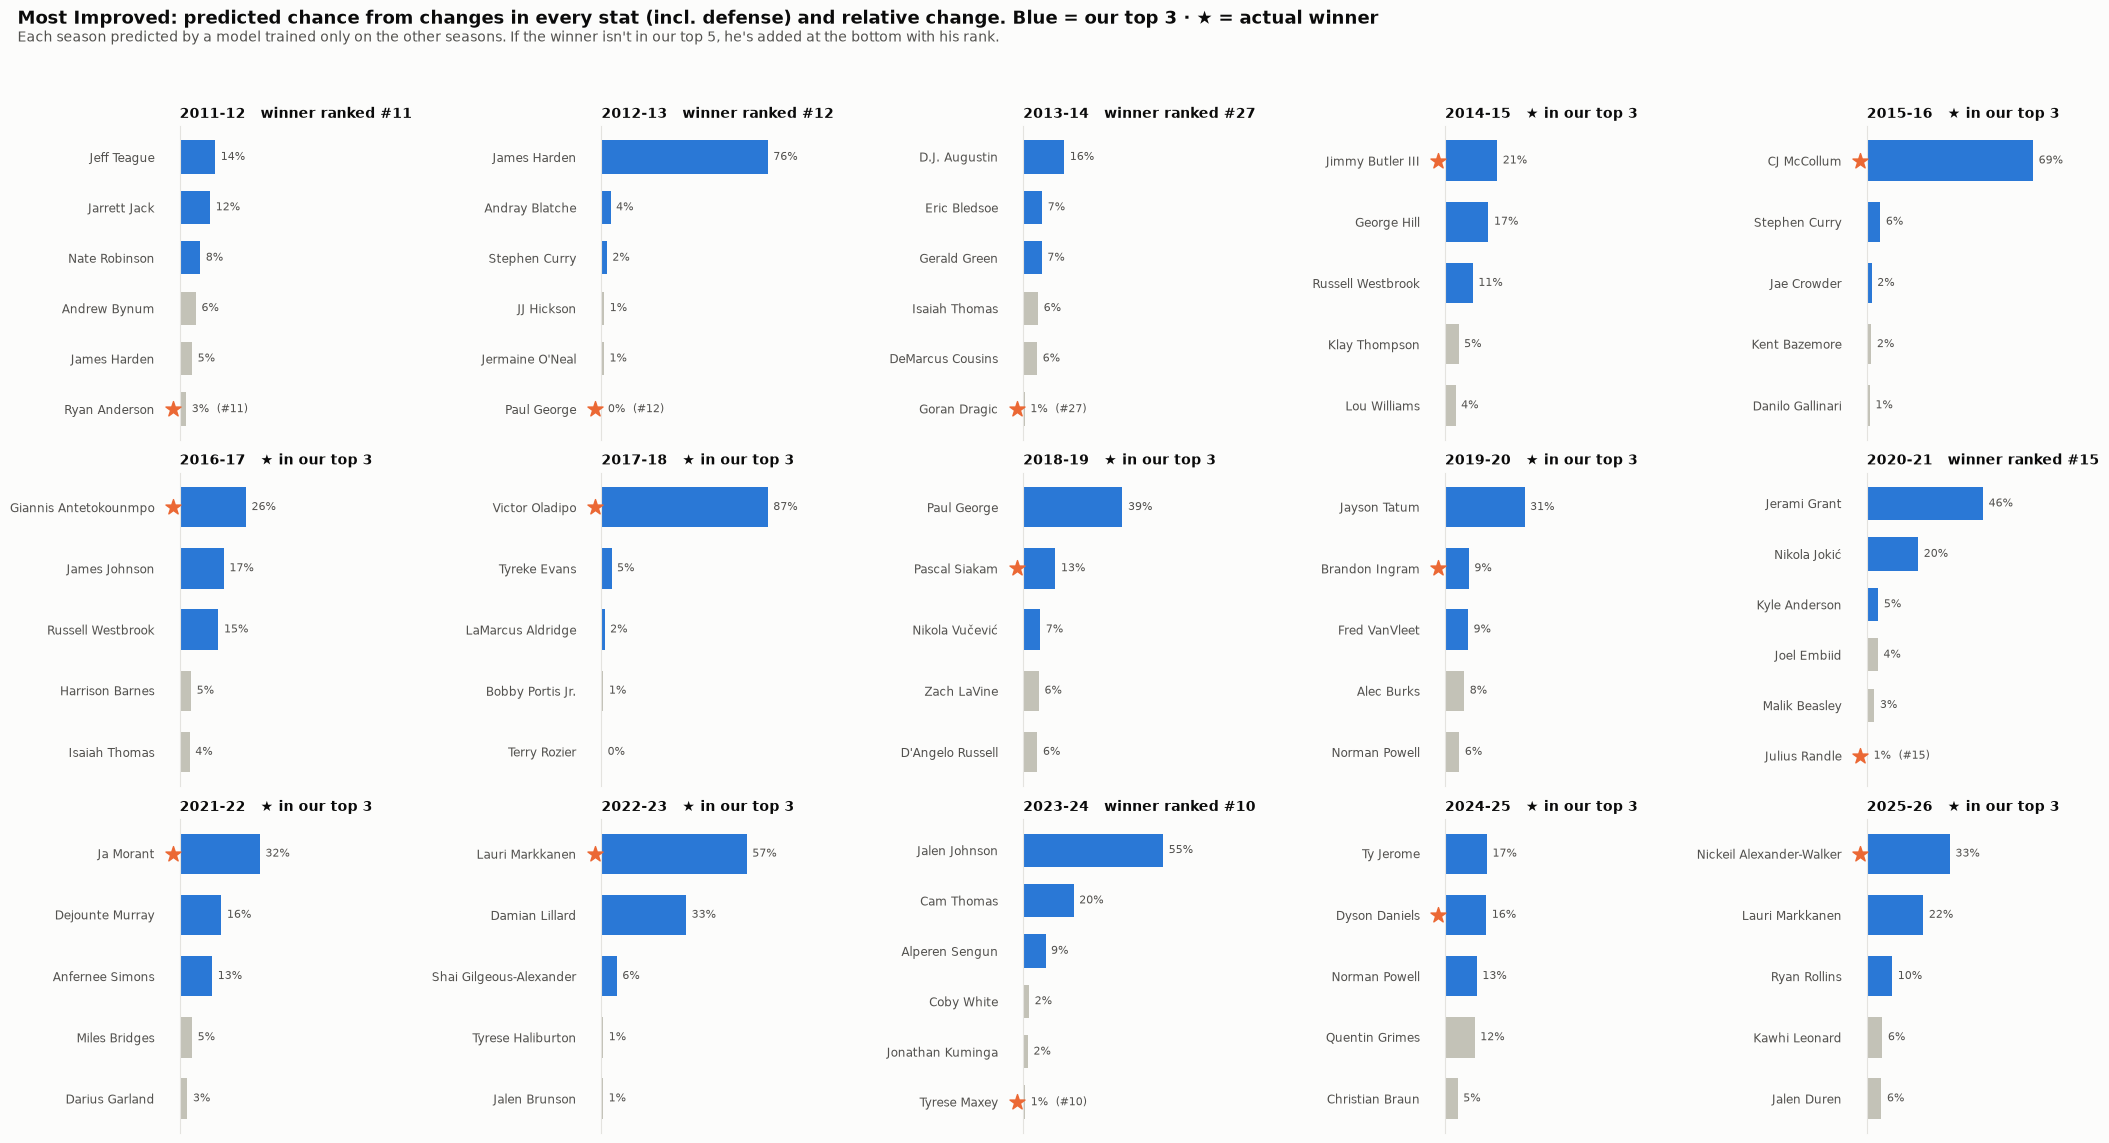

In [16]:
PF = e2.assign(p=probs2["changes + defense + relative"])
probability_bars(PF, "Most Improved: predicted chance from changes in every stat (incl. defense) and relative change. Blue = our top 3 · ★ = actual winner",
                 "Each season predicted by a model trained only on the other seasons. If the winner isn't in our top 5, he's added at the bottom with his rank.",
                 FIG_DIR / "10_mip_probability_bars_final.png");

In [17]:
PF["rank"] = PF.groupby("season")["p"].rank(ascending=False, method="min").astype(int)
check = [("Kawhi Leonard", "2018-19"), ("Kawhi Leonard", "2025-26"), ("Ty Jerome", "2024-25"), ("Nickeil Alexander-Walker", "2025-26"), ("Paul George", "2012-13"),
         ("Goran Dragic", "2013-14"), ("Julius Randle", "2020-21")]
rows = []
for n, s in check:
    a = P[(P["player_name"] == n) & (P["season"] == s)]
    b = PF[(PF["player_name"] == n) & (PF["season"] == s)]
    rows.append({"player": n, "season": s, "baseline season": int(b["base_season_start"].iloc[0]), "ppg": f"{b['base_ppg'].iloc[0]:.1f} → {b['ppg'].iloc[0]:.1f}",
                 "rank (changes only)": int(a["rank"].iloc[0]), "rank (final)": int(b["rank"].iloc[0]),
                 "chance (final)": f"{b['p'].iloc[0]:.0%}", "won": bool(b["mip"].iloc[0])})
pd.DataFrame(rows)

,player,season,baseline season,ppg,rank (changes only),rank (final),chance (final),won
0,Kawhi Leonard,2018-19,2016,25.5 → 26.6,92,80,0%,False
1,Kawhi Leonard,2025-26,2024,21.5 → 27.9,4,4,6%,False
2,Ty Jerome,2024-25,2022,6.9 → 12.5,3,1,17%,False
3,Nickeil Alexander-Walker,2025-26,2024,9.4 → 20.8,1,1,33%,True
4,Paul George,2012-13,2011,12.1 → 17.4,20,12,0%,True
5,Goran Dragic,2013-14,2012,14.7 → 20.3,19,27,1%,True
6,Julius Randle,2020-21,2019,19.5 → 24.1,18,15,1%,True


### 10G findings

- **Final model: changes + defense + relative change.** Winner #1 in **7** of 15 seasons, top 3 in **10**, median winner rank 2. Strict check (earlier seasons only): #1 in 4 of 10, top 3 in 6.
- **Defense adds a little,** in the expected direction: more steals and a *lower* defensive rating raise a player's chances. Paul George 2012-13 rises from #20 to #12; his award isn't explained by box-score defense alone.
- **Relative change works the opposite way to the intuition.** For the *same* absolute jump, voters favoured players who started from a higher base (15 → 22 beats 2 → 9), plausibly because a jump from almost nothing looks like a bench player getting minutes. The inputs are closely related, so treat this as a lead.
- **"Level reached" didn't help out of sample** (#1 in only 4); with 15 votes the extra inputs fit noise. It does show a small *discount* for players who were already good (starting game-score weight −0.4).
- **Already-elite players:** Kawhi Leonard 2025-26 sits #4 (6%); with a proper baseline, his 2018-19 "leap" disappears (#80).
- **NAW 2025-26: #1 (33%)**, the model's pick and the actual winner. In 2024-25 the model narrowly prefers Ty Jerome (17%) to the winner Dyson Daniels (#2).
- **Still not explained by the box score:** Goran Dragić 2013-14 (#27), Julius Randle 2020-21 (#15), Paul George 2012-13 (#12), Tyrese Maxey 2023-24 (#10). See 10I.

## 10H — The mid-season race: could we have called it at the All-Star break?

Same idea, but using **only games before the All-Star break**, compared with each player's full previous season. Season-long stats (usage, start rate, defensive rating) are left out; steals and blocks come from the games so far because they include the second half. Eligibility: ≥ 2 previous seasons and at least half of the games played so far.

The model is trained on mid-season data from the *other* seasons, so it learns "who, as of February, ends up winning".

In [18]:
from unicorn.mip import GAMELOG_DEFENSE, GAMELOG_DELTAS

MID = GAMELOG_DELTAS + GAMELOG_DEFENSE + RELATIVE
mid = mip_candidates(games[~games["after_all_star"]], ps, season_stats=False)
mid["mip"] = [MIP_WINNERS.get(s) == p for s, p in zip(mid["season"], mid["player_id"])]
em = mid[mid["eligible"] & (mid["season_start"] >= 2011)].reset_index(drop=True)
print("winners eligible at the break:", int(em["mip"].sum()), "/ 15")
pm = out_of_sample_probabilities(em, MID, "loso")
full_same_inputs = out_of_sample_probabilities(e2, MID, "loso")
pd.DataFrame({"at the All-Star break": summarize(em, pm), "full season, same inputs": summarize(e2, full_same_inputs),
              "full season, final model": cmp_rows["changes + defense + relative"]}).T.round(3)

winners eligible at the break: 15 / 15


,seasons,winner #1,winner top 3,median winner rank,mean winner probability,log-likelihood vs random pick,starting-level weight
at the All-Star break,15.0,7.0,9.0,2.0,0.232,3.007,NaN
"full season, same inputs",15.0,8.0,10.0,1.0,0.261,3.229,NaN
"full season, final model",15.0,7.0,10.0,2.0,0.245,3.128,NaN


,season,player_name,chance at break,rank at break,chance after season,rank after season
0,2011-12,Ryan Anderson,0.04,8,0.03,11
1,2013-14,Goran Dragic,0.02,17,0.01,27
2,2012-13,Paul George,0.00,17,0.00,12
3,2014-15,Jimmy Butler III,0.30,1,0.21,1
4,2015-16,CJ McCollum,0.67,1,0.69,1
5,2017-18,Victor Oladipo,0.82,1,0.87,1
6,2016-17,Giannis Antetokounmpo,0.23,1,0.26,1
7,2020-21,Julius Randle,0.00,19,0.01,15
8,2019-20,Brandon Ingram,0.17,1,0.09,2
9,2018-19,Pascal Siakam,0.09,2,0.13,2


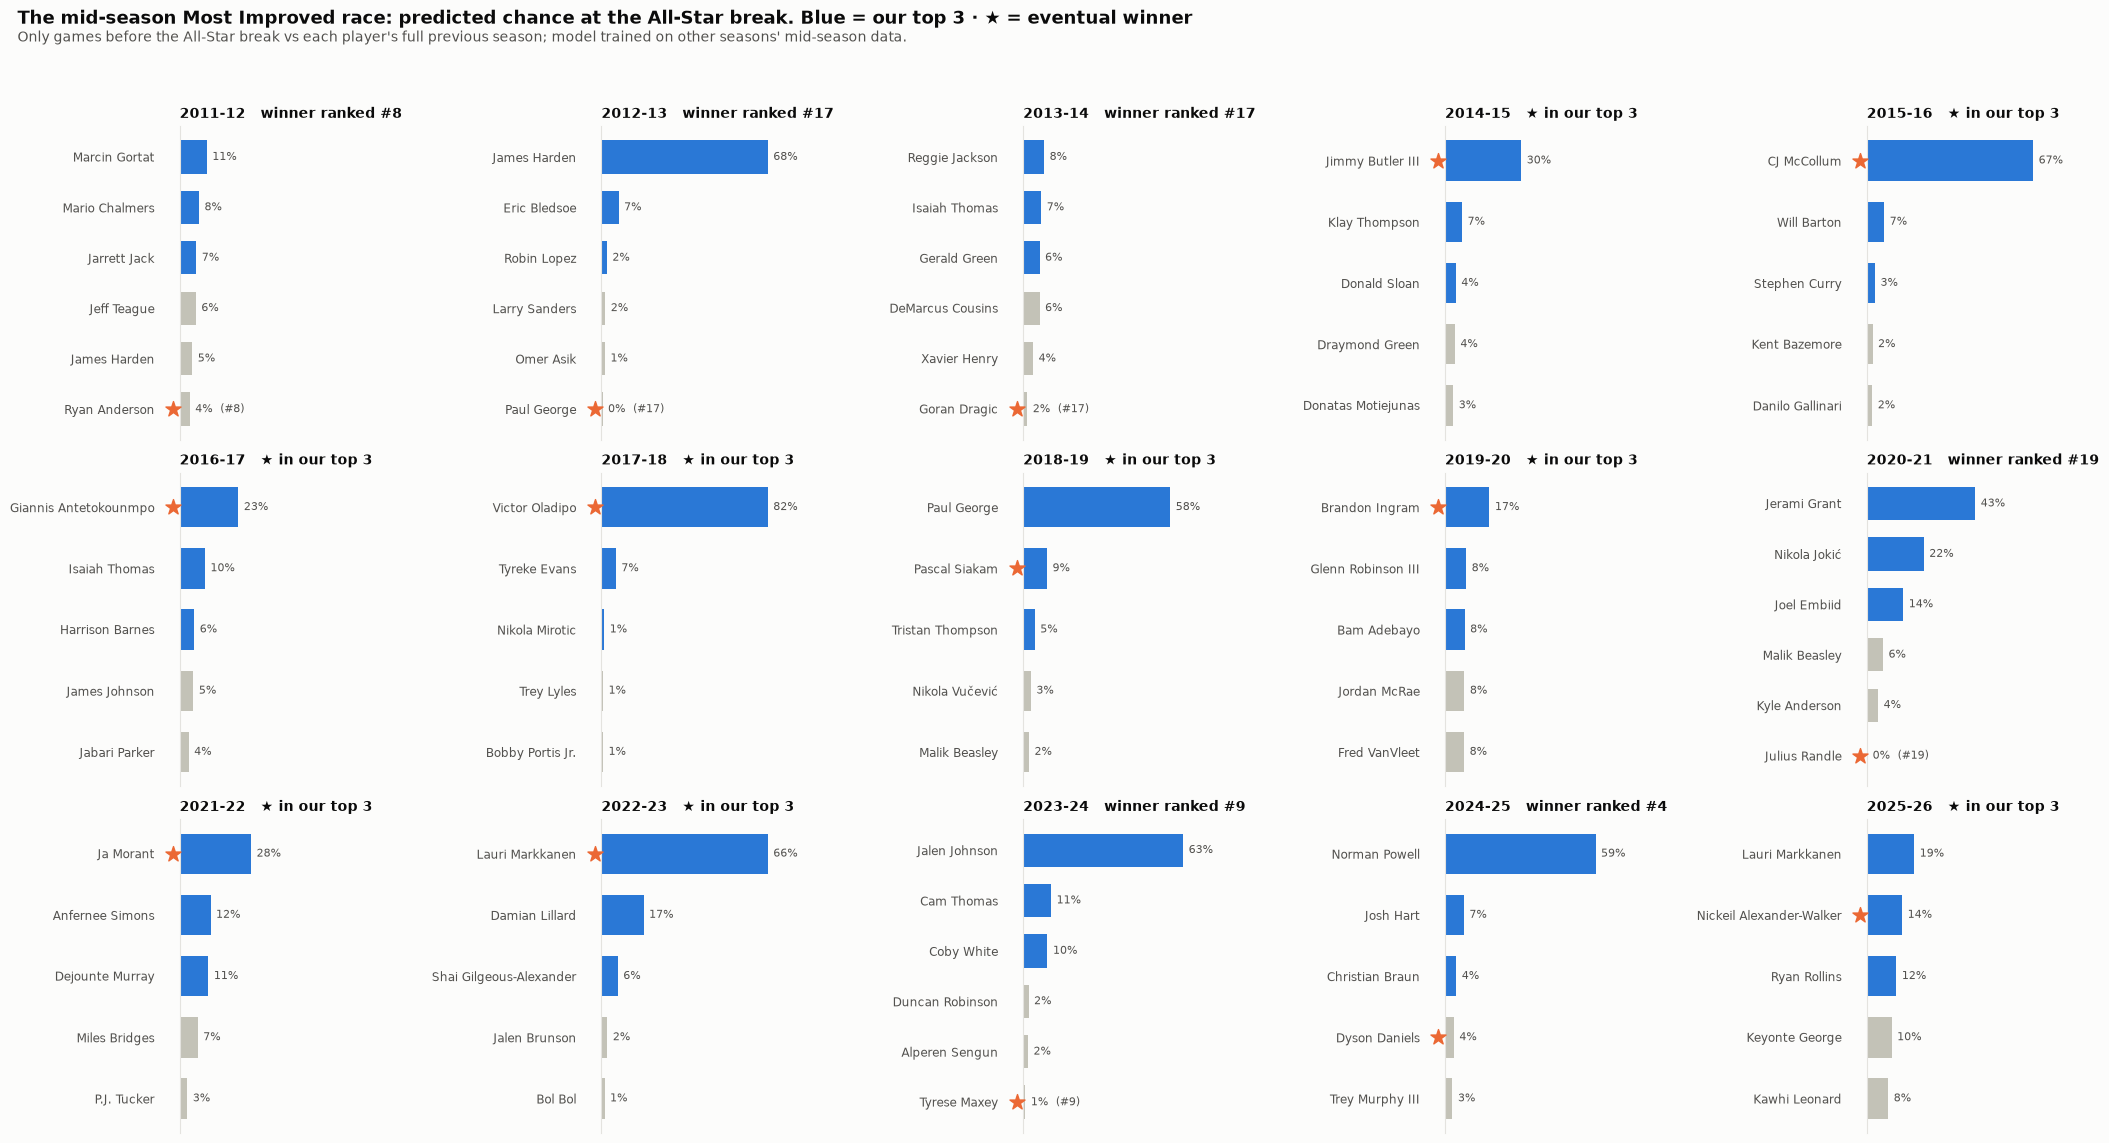

In [19]:
PM = em.assign(p=pm)
probability_bars(PM, "The mid-season Most Improved race: predicted chance at the All-Star break. Blue = our top 3 · ★ = eventual winner",
                 "Only games before the All-Star break vs each player's full previous season; model trained on other seasons' mid-season data.",
                 FIG_DIR / "10_mip_race_all_star_break.png");
PM["rank"] = PM.groupby("season")["p"].rank(ascending=False, method="min").astype(int)
race = (PM[PM["mip"]][["season", "player_name", "p", "rank"]].rename(columns={"p": "chance at break", "rank": "rank at break"})
        .merge(PF[PF["mip"]][["season", "p", "rank"]].rename(columns={"p": "chance after season", "rank": "rank after season"}), on="season"))
race.round(2)

### 10H findings

- **At the All-Star break the model already had the eventual winner #1 in 7 of 15 seasons**, and in the top 3 in 9, close to what the full season gives (7–8 #1). Voters' narratives appear largely set by February.
- **Called at the break:** Butler, McCollum, Giannis, Oladipo, Ingram, Morant, Markkanen were all #1 in February.
- **Rose late:** NAW was #2 at the break (14%) and #1 by season's end; Siakam #2 at both points; Dyson Daniels #4 → #2.
- **Never on the radar:** Julius Randle (#19 at the break, #15 after), Goran Dragić (#17 → #27), Paul George (#17 → #12).

## 10I — Why the misses? Side by side with the model's picks

For each puzzling case, the model's score is broken into the contribution of each kind of change (relative to that season's average candidate), next to the model's top picks. **Context columns (age, team record, baseline size) are not model inputs**; they're there to show what voters may have seen that the model can't.

In [20]:
from unicorn.mip import DEFENSE, RELATIVE

FINAL = DELTAS + DEFENSE + RELATIVE
PFm = e2.assign(p=probs2["changes + defense + relative"])
PFm["rank"] = PFm.groupby("season")["p"].rank(ascending=False, method="min").astype(int)
team_games = games.drop_duplicates(["team_id", "game_id"]).assign(win=lambda x: x["wl"].eq("W"))
team_win = team_games.groupby(["team_abbreviation", "season_start"])["win"].mean()
GROUP = {"ppg_delta": "scoring jump", "game_score_delta": "all-round jump", "usg_delta": "usage jump", "rpg_delta": "other box stats",
         "apg_delta": "other box stats", "ts_delta": "efficiency", "spg_delta": "defense", "bpg_delta": "defense",
         "def_rating_delta": "defense", "mpg_delta": "more minutes (−)", "start_rate_delta": "became starter (−)",
         "ppg_rel": "relative jump (−)", "game_score_rel": "relative jump (−)"}

def why(season, focus):
    m = ChoiceModel(FINAL, l2=1.0).fit(e2[e2["season"] != season])   # a model that never saw this season
    d = e2[e2["season"] == season]
    Z = pd.DataFrame(m._design(d), index=d.index, columns=FINAL)
    C = ((Z - Z.mean()) * m.coef_).T.groupby(lambda f: GROUP[f]).sum().T
    C["TOTAL score"] = C.sum(axis=1)
    ranked = PFm[PFm["season"] == season]
    names = list(dict.fromkeys(ranked.nsmallest(2, "rank")["player_name"].tolist() + [focus] + ranked.loc[ranked["mip"], "player_name"].tolist()))
    keep = d["player_name"].isin(names)
    out = C[keep].copy(); out.index = d.loc[keep, "player_name"]
    ctx, r = d[keep].set_index("player_name"), ranked.set_index("player_name")
    y = int(season[:4])
    out["model rank"] = r.loc[out.index, "rank"]; out["chance"] = r.loc[out.index, "p"].round(3); out["won MIP"] = ctx["mip"]
    out["ppg"] = [f"{a:.1f} → {b:.1f}" for a, b in zip(ctx["base_ppg"], ctx["ppg"])]
    out["minutes"] = [f"{a:.0f} → {b:.0f}" for a, b in zip(ctx["base_mpg"], ctx["mpg"])]
    out["game score"] = [f"{a:.1f} → {b:.1f}" for a, b in zip(ctx["base_game_score"], ctx["game_score"])]
    out["baseline season (games)"] = [f"{int(a)} ({int(n)})" for a, n in zip(ctx["base_season_start"], ctx["base_games"])]
    out["age (context)"] = ctx["age"].round(1)
    out["team win % (context)"] = [f"{team_win.get((t, y - 1), np.nan):.0%} → {team_win.get((t, y), np.nan):.0%}" for t in ctx["team"]]
    return out.round(2).T

for season, focus in [("2023-24", "Tyrese Maxey"), ("2012-13", "Paul George"), ("2020-21", "Julius Randle"),
                      ("2013-14", "Goran Dragic"), ("2025-26", "Kawhi Leonard"), ("2018-19", "Derrick Rose")]:
    print(f"{season}: why {focus}?")
    display(why(season, focus))

2023-24: why Tyrese Maxey?


player_name,Tyrese Maxey,Jalen Johnson,Cam Thomas
all-round jump,3.84,6.84,5.57
became starter (−),-0.29,-0.73,-0.61
defense,-0.08,0.48,0.3
efficiency,-0.31,0.29,-0.12
more minutes (−),-0.44,-1.82,-1.44
other box stats,-0.24,1.13,0.27
relative jump (−),-0.76,-2.32,-1.82
scoring jump,3.01,5.26,5.97
usage jump,0.89,0.7,0.7
TOTAL score,5.62,9.84,8.82


2012-13: why Paul George?


player_name,Andray Blatche,James Harden,Paul George
all-round jump,2.24,4.89,2.64
became starter (−),-0.0,0.01,0.0
defense,0.88,1.26,0.41
efficiency,0.9,-0.47,-0.21
more minutes (−),0.83,-1.31,-1.52
other box stats,-0.04,-0.04,0.08
relative jump (−),-0.44,-0.93,-0.75
scoring jump,0.85,4.15,2.46
usage jump,0.89,1.44,0.82
TOTAL score,6.12,9.01,3.93


2020-21: why Julius Randle?


...

player_name,D.J. Augustin,Goran Dragic,Eric Bledsoe
all-round jump,3.85,2.1,4.24
became starter (−),-0.05,0.01,-0.59
defense,0.45,-0.26,0.39
efficiency,0.27,0.45,0.45
more minutes (−),-1.4,-0.19,-1.56
other box stats,0.64,-0.3,0.99
relative jump (−),-2.14,-0.74,-1.68
scoring jump,3.56,2.32,3.94
usage jump,1.79,0.7,0.63
TOTAL score,6.96,4.09,6.81


2025-26: why Kawhi Leonard?


player_name,Kawhi Leonard,Lauri Markkanen,Nickeil Alexander-Walker
all-round jump,4.17,4.95,5.57
became starter (−),0.01,0.01,-0.77
defense,0.09,0.59,0.67
efficiency,0.25,0.23,0.19
more minutes (−),-0.03,-0.32,-0.87
other box stats,0.17,0.31,0.14
relative jump (−),-0.78,-1.07,-2.16
scoring jump,2.64,3.25,4.86
usage jump,0.85,0.69,1.41
TOTAL score,7.36,8.65,9.03


2018-19: why Derrick Rose?


player_name,Derrick Rose,Paul George,Pascal Siakam
all-round jump,0.27,4.02,5.22
became starter (−),0.9,-0.05,-1.24
defense,0.19,0.63,0.24
efficiency,0.09,0.05,0.26
more minutes (−),0.62,-0.17,-1.72
other box stats,-0.3,0.61,0.59
relative jump (−),-0.05,-0.72,-2.01
scoring jump,0.01,2.88,4.55
usage jump,0.14,0.64,0.87
TOTAL score,1.87,7.88,6.76


### 10I findings

The model measures **how big the statistical jump was**. The winners it misses had **moderate jumps that mattered more for who they became**:

- **Tyrese Maxey 2023-24 (#10):** 20.3 → 25.9 ppg. Jalen Johnson (5.6 → 16.0) and Cam Thomas (10.6 → 22.5) roughly *doubled* their output, so their jumps dwarf his. Maxey's leap was from good to All-Star first option, a smaller jump in raw numbers.
- **Paul George 2012-13 (#12):** 12.1 → 17.4 ppg while his minutes rose 30 → 38 (which counts against him). James Harden's traded-to-Houston jump (16.8 → 25.9) dominates. George's rise was largely defensive and to All-Star status.
- **Julius Randle 2020-21 (#15):** 19.5 → 24.1 ppg. Jerami Grant (12.0 → 22.3 on a 28%-win team) and Nikola Jokić had bigger jumps; **the Knicks went from 32% to 57% wins**.
- **Goran Dragić 2013-14 (#27):** 14.7 → 20.3 ppg. His own teammate Eric Bledsoe had the bigger jump (8.5 → 17.7); **the Suns went from 30% to 59% wins** and voters credited Dragić.
- **Kawhi Leonard 2025-26 (#4, 6%):** a genuine jump (21.5 → 27.9 ppg vs a 37-game season), but voters don't treat a **34-year-old former MVP** as an improving player.
- **Derrick Rose 2018-19:** fixed by the 33% floor. His 25-game 2017-18 is skipped and against 2016-17 there is no leap (18.0 → 18.0 ppg); he falls to #51.

**Takeaway:** the remaining misses are limits of box-score changes, not data errors. **Team success** (Randle, Dragić) and **age or status** (Kawhi; Maxey and George's jump to All-Star level) are the obvious next inputs. Both are parked for later.

## 10J — Team success, ΔX vs Δ%, and age; our top 7 vs the real top 7

New inputs:
- **Team success:** change in team win % (his team this season vs his team in the baseline season).
- **Δ% for every stat** (points, rebounds, assists, steals, blocks, minutes, game score, true shooting, usage, defensive rating), so **ΔX (absolute change) and Δ% (relative change)** can be compared head to head.
- **Age** is back.

**Evaluation against the real voting:** each season's actual top 7 by voting points, from Basketball-Reference ([e.g. 2025-26](https://www.basketball-reference.com/awards/awards_2026.html)). **Votes are used only to evaluate and display, never to train the model.** Pages are fetched politely and cached in `data/raw/bref/`.

In [21]:
from unicorn.bref import all_mip_voting, attach_player_ids
from unicorn.mip import ABSOLUTE_ALL, AGE, RELATIVE_ALL, TEAM, top_k_overlap, top7_vs_votes_chart

votes = attach_player_ids(all_mip_voting(), games)
print("voting rows:", len(votes), "| matched to NBA.com players:", votes["player_id"].notna().mean().round(3))
c3 = mip_candidates(games, ps)
c3["mip"] = [MIP_WINNERS.get(s) == p for s, p in zip(c3["season"], c3["player_id"])]
e3 = c3[c3["eligible"] & (c3["season_start"] >= 2011)].reset_index(drop=True)

real7 = votes[votes["vote_rank"] <= 7].merge(c3[["season", "player_id", "eligible", "prior_seasons"]], on=["season", "player_id"], how="left")
print(f"real top-7 players eligible under our rules: {real7['eligible'].fillna(False).mean():.0%}")
print("not eligible:", ", ".join(f"{r.player} ({r.season}, {'year 2' if r.prior_seasons == 1 else 'year 1' if r.prior_seasons == 0 else 'other'})"
                                 for r in real7[~real7["eligible"].fillna(False).astype(bool)].itertuples()))

voting rows: 329 | matched to NBA.com players: 1.0


real top-7 players eligible under our rules: 80%
not eligible: Nikola Peković (2011-12, year 2), Greg Monroe (2011-12, year 2), Jeremy Lin (2011-12, year 2), Nikola Vučević (2012-13, year 2), Anthony Davis (2013-14, year 2), Rudy Gobert (2014-15, year 2), Hassan Whiteside (2014-15, other), Giannis Antetokounmpo (2014-15, year 2), Nikola Jokić (2016-17, year 2), Jaylen Brown (2017-18, year 2), De'Aaron Fox (2018-19, year 2), Luka Dončić (2019-20, year 2), Devonte' Graham (2019-20, year 2), Shai Gilgeous-Alexander (2019-20, year 2), Michael Porter Jr. (2020-21, year 2), Desmond Bane (2021-22, year 2), Tyrese Maxey (2021-22, year 2), Trey Murphy III (2022-23, year 2), Jalen Williams (2023-24, year 2), Amen Thompson (2024-25, year 2), Reed Sheppard (2025-26, year 2)


In [22]:
SETS3 = {"ΔX only": ABSOLUTE_ALL, "Δ% only": RELATIVE_ALL, "ΔX + Δ%": ABSOLUTE_ALL + RELATIVE_ALL,
         "ΔX + team": ABSOLUTE_ALL + TEAM, "ΔX + Δ% + team": ABSOLUTE_ALL + RELATIVE_ALL + TEAM,
         "ΔX + team + age": ABSOLUTE_ALL + TEAM + AGE, "ΔX + Δ% + team + age": ABSOLUTE_ALL + RELATIVE_ALL + TEAM + AGE}
probs3, rows = {}, {}
for name, feats in SETS3.items():
    probs3[name] = out_of_sample_probabilities(e3, feats, "loso")
    rows[name] = {**summarize(e3, probs3[name]), "avg of our top 7 in real top 7": top_k_overlap(e3, probs3[name], votes)["overlap"].mean()}
comparison = pd.DataFrame(rows).T.drop(columns="seasons")
comparison.round(3)

,winner #1,winner top 3,median winner rank,mean winner probability,log-likelihood vs random pick,avg of our top 7 in real top 7
ΔX only,6.0,10.0,2.0,0.256,3.106,2.667
Δ% only,5.0,8.0,3.0,0.181,2.542,2.400
ΔX + Δ%,6.0,9.0,2.0,0.222,3.029,2.733
ΔX + team,7.0,9.0,2.0,0.228,3.043,2.933
ΔX + Δ% + team,8.0,9.0,1.0,0.238,3.127,3.067
ΔX + team + age,8.0,10.0,1.0,0.244,3.150,2.933
ΔX + Δ% + team + age,9.0,9.0,1.0,0.252,3.254,2.867


final model, strict check (earlier seasons only): {'seasons': 10, 'winner #1': 5, 'winner top 3': 6, 'median winner rank': 1.5, 'mean winner probability': 0.232, 'log-likelihood vs random pick': 3.417}


mpg_rel            -0.88
age                -0.72
ppg_rel            -0.33
start_rate_delta   -0.24
rpg_rel            -0.19
bpg_delta          -0.13
apg_rel            -0.12
def_rating_rel     -0.08
def_rating_delta   -0.08
spg_rel            -0.06
mpg_delta          -0.06
ts_rel             -0.02
game_score_rel      0.06
bpg_rel             0.06
apg_delta           0.15
ts_delta            0.27
usg_delta           0.28
usg_rel             0.34
spg_delta           0.35
rpg_delta           0.39
team_win_delta      0.46
ppg_delta           1.41
game_score_delta    1.48
dtype: float64

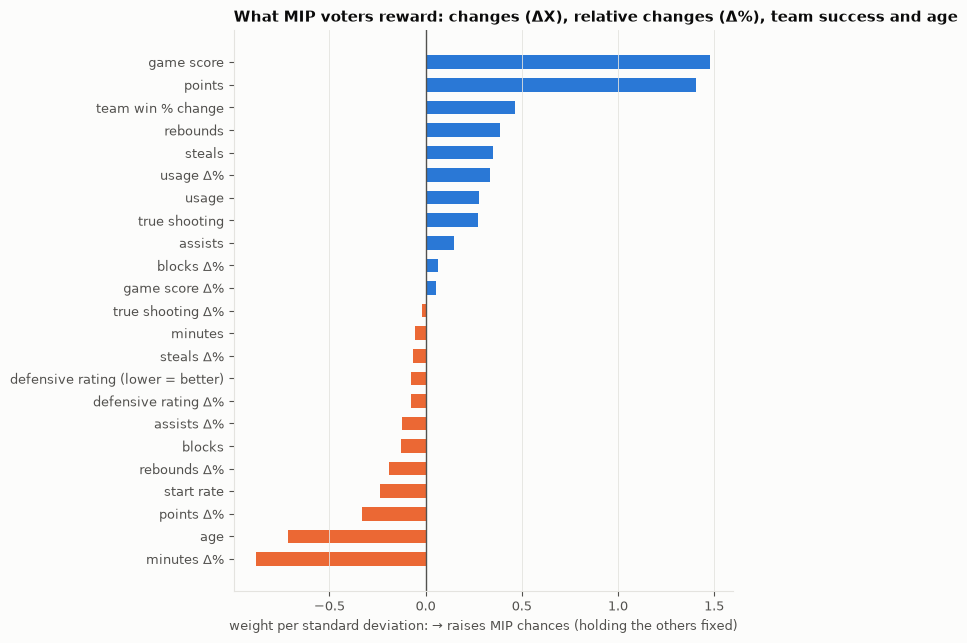

In [23]:
FINAL3 = SETS3["ΔX + Δ% + team + age"]
strict3 = summarize(e3, out_of_sample_probabilities(e3, FINAL3, "walk_forward"))
print("final model, strict check (earlier seasons only):", {k: round(v, 3) for k, v in strict3.items()})
w3 = ChoiceModel(FINAL3, l2=1.0).fit(e3).coefficients().sort_values()
nice = {**names, "rpg_rel": "rebounds Δ%", "apg_rel": "assists Δ%", "spg_rel": "steals Δ%", "bpg_rel": "blocks Δ%",
        "mpg_rel": "minutes Δ%", "ts_rel": "true shooting Δ%", "usg_rel": "usage Δ%", "def_rating_rel": "defensive rating Δ%",
        "ppg_rel": "points Δ%", "game_score_rel": "game score Δ%", "team_win_delta": "team win % change", "age": "age"}
fig, ax = plt.subplots(figsize=(7.5, 6.5))
ax.barh([nice.get(c, c) for c in w3.index], w3.values, color=np.where(w3 > 0, BLUE, ORANGE), height=0.6)
ax.axvline(0, color=INK2, linewidth=1); ax.grid(axis="y", visible=False)
ax.set_xlabel("weight per standard deviation: → raises MIP chances (holding the others fixed)")
ax.set_title("What MIP voters reward: changes (ΔX), relative changes (Δ%), team success and age", loc="left")
fig.tight_layout(); fig.savefig(FIG_DIR / "10_mip_vote_weights_team_age.png", dpi=150, bbox_inches="tight")
w3.round(2)

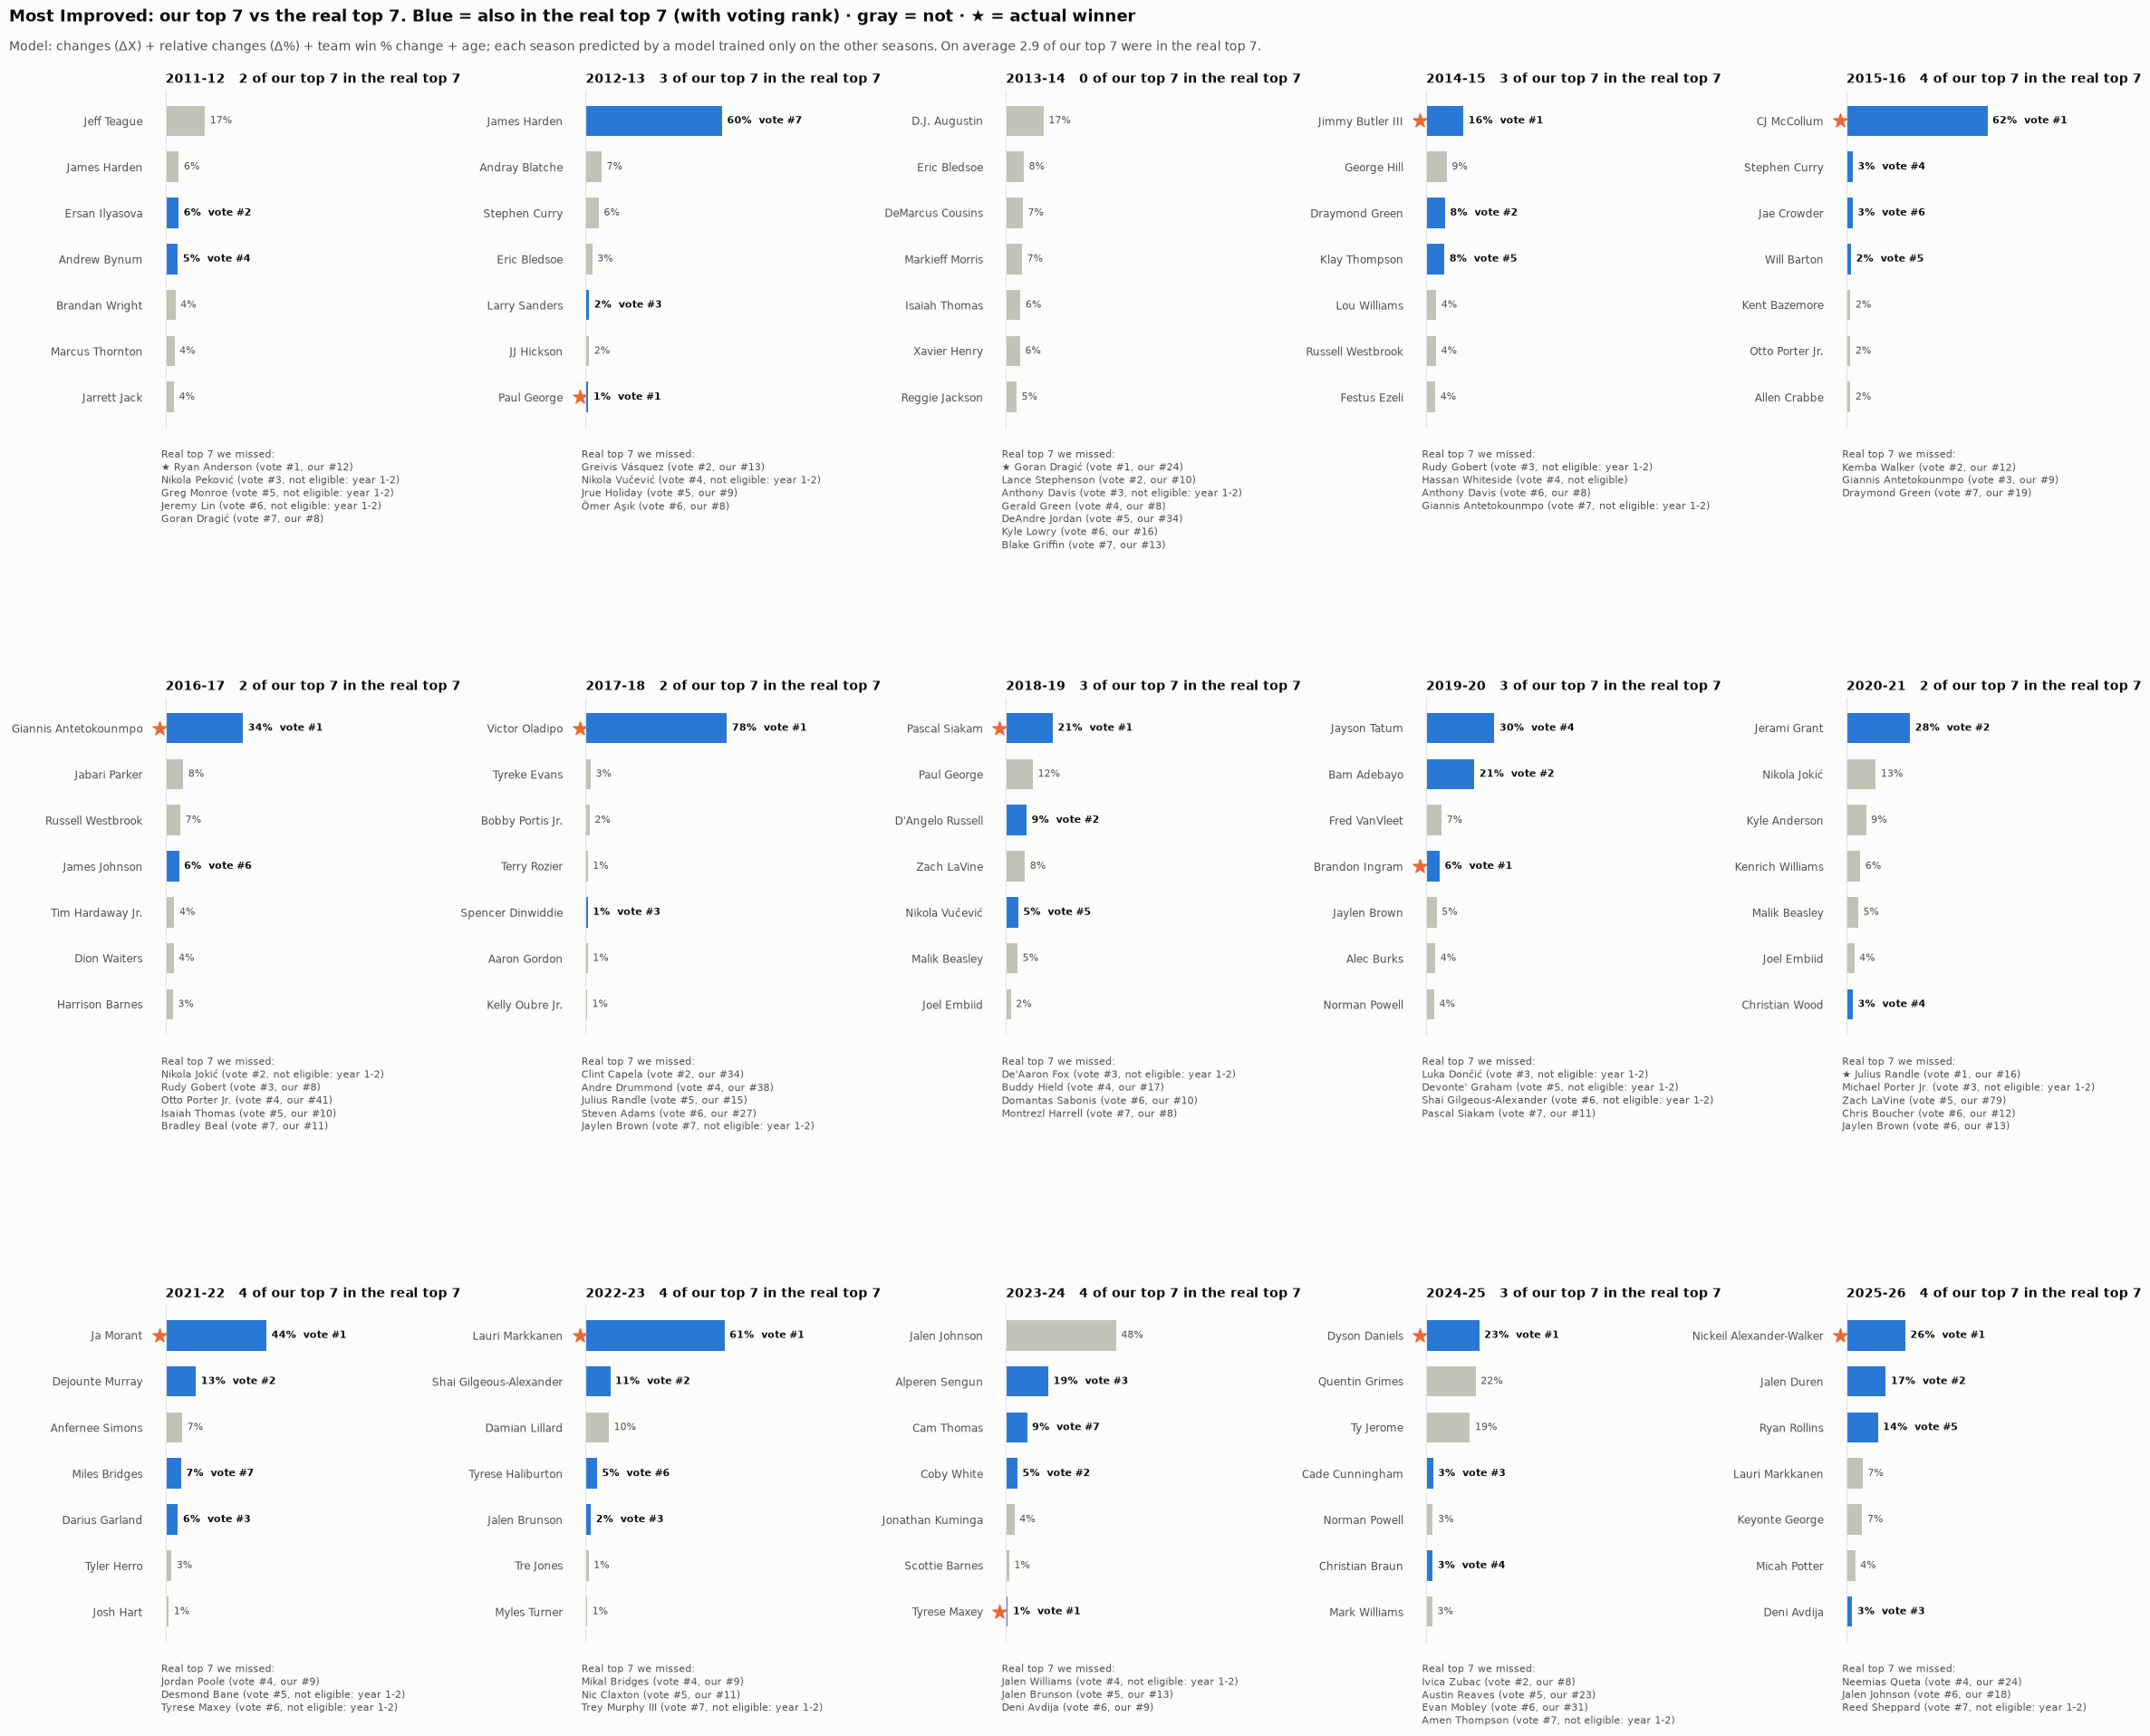

In [24]:
P3 = e3.assign(p=probs3["ΔX + Δ% + team + age"])
top7_vs_votes_chart(P3, votes, c3,
    "Most Improved: our top 7 vs the real top 7. Blue = also in the real top 7 (with voting rank) · gray = not · ★ = actual winner",
    "Model: changes (ΔX) + relative changes (Δ%) + team win % change + age; each season predicted by a model trained only on the other seasons. "
    "On average {avg:.1f} of our top 7 were in the real top 7.",
    FIG_DIR / "10_mip_top7_vs_real.png");

### 10J findings

**ΔX beats Δ%.** On its own, absolute change picks the winner #1 in 6 seasons (top 3 in 10) against 5 (top 3 in 8) for relative change, and fits the votes much better (3.11 vs 2.54). Voters reward the **size** of the jump; Δ% adds a little only alongside ΔX.

**Team success matters.** A rising team record raises a player's chances (weight +0.46). Adding it lifts the average overlap between our top 7 and the real top 7 from 2.7 to about 3.0.

**Age matters too** (weight −0.72): with ΔX + Δ% + team + age, the model has the **winner #1 in 9 of 15 seasons** and fits the votes best (3.25). Strict check (earlier seasons only): #1 in 5 of 10.

**Our top 7 vs the real top 7:** on average **2.9 of our 7** were in the real top 7. Two limits:
- **20% of real top-7 players aren't eligible under our rules**: mostly second-year players (Luka Dončić, Shai Gilgeous-Alexander, Nikola Jokić, Giannis Antetokounmpo, Tyrese Maxey 2021-22, Jalen Williams, Amen Thompson, Reed Sheppard…). Voters do consider sophomores, so the best possible overlap with our rules is about 5.6, not 7.
- Voters also rank players whose box-score jump is modest but whose role or team changed (e.g. 2013-14: 0 of 7, with Dragić at our #24).

**Remaining misses:** team success moves Randle (#16) and Dragić (#24) only a little; their votes reflect more than team record. Paul George 2012-13 and Tyrese Maxey 2023-24 now make our top 7 (both #7).